# Penn-Fudan Pedestrian Instance Segmentation (TensorFlow) — ROI-Based Stage-2 Project

**Goal (Full mini-project):**  
Dataset download → preprocessing → ROI/target generation → train a **simplified Mask R-CNN Stage-2** model (TensorFlow/Keras) → evaluate → visualize outputs.

## Important note (read first)
This notebook trains the **Stage-2 ROI head** for instance segmentation (class + bbox refinement + mask).  
It is **not full end-to-end Mask R-CNN** because it does **not** include RPN/anchors/NMS.

✅ Great for learning and building a working project pipeline  
✅ Later you can replace proposals with **YOLO boxes** for real deployment

---

## What problem this solves
**Single-class pedestrian instance segmentation** on **Penn-Fudan Pedestrians** dataset:
- Detect pedestrian ROI (provided/simulated proposals in this notebook)
- Predict per-instance mask
- Refine bbox

## Notebook Outline (Bangla)
- **Dataset**: Penn-Fudan (pedestrian images + instance masks)
- **Preprocess**: image resize + instance mask parsing
- **Training Pipeline**: GT boxes/masks → ROIs + targets
- **Model**: Backbone + FPN + ROIAlign + Box Head + Mask Head
- **Train**
- **Evaluate** (loss, class acc, mask IoU/Dice)
- **Show output visualization**

> **Note:** Inference/demo visualization here uses **proposal ROIs** (GT + jitter/random) for Stage-2 testing.  
> Real deployment-এ proposal source হিসেবে **YOLO detector** use করো।

In [1]:
import os
import io
import math
import time
import json
import random
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TARGET_H = 384
TARGET_W = 384
NUM_CLASSES = 2   # 0=background, 1=person

BATCH_SIZE = 2
ROIS_PER_IMAGE = 96
POSITIVE_FRACTION = 0.25
MASK_SIZE = 28
EPOCHS = 8
LR = 1e-4

## 1) Download + Prepare Dataset (Penn-Fudan)
Penn-Fudan has:
- RGB images
- Pedestrian instance masks (each person has different mask id)

We'll resize to a fixed size and reconstruct boxes/masks from the resized mask image.

In [3]:
DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
PENN_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
ZIP_PATH = DATA_ROOT / "PennFudanPed.zip"
EXTRACT_DIR = DATA_ROOT / "PennFudanPed"

def download_and_extract_penn_fudan():
    if EXTRACT_DIR.exists() and (EXTRACT_DIR / "PNGImages").exists():
        print("Dataset already exists:", EXTRACT_DIR)
        return EXTRACT_DIR

    if not ZIP_PATH.exists():
        print("Downloading dataset...")
        urllib.request.urlretrieve(PENN_URL, ZIP_PATH)
        print("Downloaded:", ZIP_PATH)

    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_ROOT)

    print("Done:", EXTRACT_DIR)
    return EXTRACT_DIR

_ = download_and_extract_penn_fudan()

Downloaded: data/PennFudanPed.zip
Extracting...
Done: data/PennFudanPed


In [4]:
def parse_instance_masks_and_boxes(mask_arr):
    # mask_arr: [H, W] integer ids, background=0
    obj_ids = np.unique(mask_arr)
    obj_ids = obj_ids[obj_ids != 0]

    instance_masks = []
    boxes = []
    classes = []

    for obj_id in obj_ids:
        m = (mask_arr == obj_id).astype(np.uint8)
        ys, xs = np.where(m > 0)
        if len(xs) == 0 or len(ys) == 0:
            continue
        x1, x2 = xs.min(), xs.max() + 1
        y1, y2 = ys.min(), ys.max() + 1
        if (x2 - x1) < 2 or (y2 - y1) < 2:
            continue
        instance_masks.append(m.astype(np.float32))
        boxes.append([x1, y1, x2, y2])   # xyxy
        classes.append(1)                 # person

    if len(instance_masks) == 0:
        instance_masks = np.zeros((0, mask_arr.shape[0], mask_arr.shape[1]), dtype=np.float32)
        boxes = np.zeros((0, 4), dtype=np.float32)
        classes = np.zeros((0,), dtype=np.int32)
    else:
        instance_masks = np.stack(instance_masks, axis=0).astype(np.float32)
        boxes = np.array(boxes, dtype=np.float32)
        classes = np.array(classes, dtype=np.int32)

    return boxes, classes, instance_masks

def load_penn_fudan_resized(extract_dir, target_h=384, target_w=384, max_samples=None):
    img_dir = Path(extract_dir) / "PNGImages"
    mask_dir = Path(extract_dir) / "PedMasks"

    img_files = sorted(list(img_dir.glob("*.png")))
    mask_files = sorted(list(mask_dir.glob("*.png")))
    assert len(img_files) == len(mask_files), "Mismatch images and masks."

    if max_samples is not None:
        img_files = img_files[:max_samples]
        mask_files = mask_files[:max_samples]

    data = []
    for img_path, mask_path in zip(img_files, mask_files):
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)  # palette/index image

        img_r = img.resize((target_w, target_h), resample=Image.BILINEAR)
        mask_r = mask.resize((target_w, target_h), resample=Image.NEAREST)

        img_arr = np.asarray(img_r).astype(np.float32) / 255.0
        mask_arr = np.asarray(mask_r)

        boxes, classes, masks = parse_instance_masks_and_boxes(mask_arr)

        sample = {
            "image": img_arr,              # [H,W,3] float32 0..1
            "boxes_xyxy": boxes,           # [M,4]
            "classes": classes,            # [M]
            "masks": masks,                # [M,H,W]
            "image_id": img_path.stem
        }
        data.append(sample)

    return data

dataset_all = load_penn_fudan_resized(EXTRACT_DIR, TARGET_H, TARGET_W)
print("Total samples:", len(dataset_all))
print("Sample keys:", dataset_all[0].keys())
print("Sample image shape:", dataset_all[0]["image"].shape)
print("Sample num instances:", len(dataset_all[0]["boxes_xyxy"]))

Total samples: 170
Sample keys: dict_keys(['image', 'boxes_xyxy', 'classes', 'masks', 'image_id'])
Sample image shape: (384, 384, 3)
Sample num instances: 2


In [5]:
# Train/Val split
indices = np.arange(len(dataset_all))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

val_size = max(20, int(0.15 * len(indices)))
val_idx = indices[:val_size]
train_idx = indices[val_size:]

train_data = [dataset_all[i] for i in train_idx]
val_data = [dataset_all[i] for i in val_idx]

print("Train:", len(train_data), "Val:", len(val_data))

Train: 145 Val: 25


## 2) Quick Data Visualization

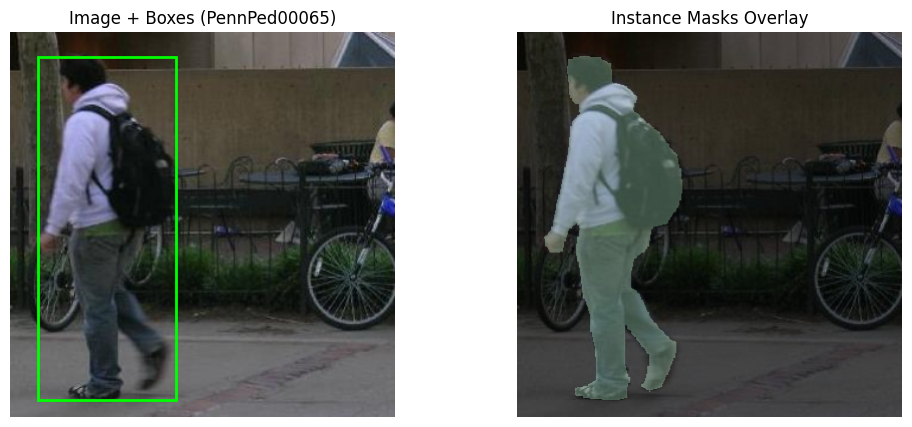

In [6]:
def draw_boxes_on_image(image, boxes, color=(0, 1, 0), linewidth=2):
    plt.imshow(image)
    ax = plt.gca()
    for b in boxes:
        x1, y1, x2, y2 = b
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=linewidth)
        ax.add_patch(rect)
    plt.axis("off")

def show_sample(sample):
    img = sample["image"]
    boxes = sample["boxes_xyxy"]
    masks = sample["masks"]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    draw_boxes_on_image(img, boxes)
    plt.title(f'Image + Boxes ({sample["image_id"]})')

    plt.subplot(1, 2, 2)
    overlay = np.zeros_like(img)
    if len(masks) > 0:
        colors = np.random.RandomState(0).rand(len(masks), 3)
        for i, m in enumerate(masks):
            overlay[m > 0.5] = colors[i]
    vis = 0.6 * img + 0.4 * overlay
    plt.imshow(vis)
    plt.title("Instance Masks Overlay")
    plt.axis("off")
    plt.show()

show_sample(train_data[0])

## 3) Box / ROI / Target Utilities
এই section-এ ROI generation + matching + mask target pipeline থাকবে.

In [7]:
# ============================================================
# Basic box utilities (xyxy absolute pixel format)
# ============================================================

def clip_boxes_xyxy(boxes, h, w):
    boxes = boxes.copy().astype(np.float32)
    if len(boxes) == 0:
        return boxes.reshape(0, 4)
    boxes[:, 0] = np.clip(boxes[:, 0], 0, w - 1)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, h - 1)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, w - 1)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, h - 1)
    return boxes

def filter_valid_boxes_xyxy(boxes, min_size=2.0):
    if len(boxes) == 0:
        return np.zeros((0,), dtype=bool)
    bw = boxes[:, 2] - boxes[:, 0]
    bh = boxes[:, 3] - boxes[:, 1]
    return (bw >= min_size) & (bh >= min_size)

def xyxy_to_yxyx_normalized(boxes_xyxy, h, w):
    if len(boxes_xyxy) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    boxes = boxes_xyxy.astype(np.float32)
    x1 = boxes[:, 0] / float(w)
    y1 = boxes[:, 1] / float(h)
    x2 = boxes[:, 2] / float(w)
    y2 = boxes[:, 3] / float(h)
    out = np.stack([y1, x1, y2, x2], axis=1)
    return np.clip(out, 0.0, 1.0).astype(np.float32)

def yxyx_normalized_to_xyxy_abs(rois, h, w):
    if len(rois) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    rois = rois.astype(np.float32)
    y1 = rois[:, 0] * h
    x1 = rois[:, 1] * w
    y2 = rois[:, 2] * h
    x2 = rois[:, 3] * w
    return np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)

def compute_iou_matrix_xyxy(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    b1 = boxes1[:, None, :]
    b2 = boxes2[None, :, :]

    inter_x1 = np.maximum(b1[..., 0], b2[..., 0])
    inter_y1 = np.maximum(b1[..., 1], b2[..., 1])
    inter_x2 = np.minimum(b1[..., 2], b2[..., 2])
    inter_y2 = np.minimum(b1[..., 3], b2[..., 3])

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area1 = np.maximum(0.0, b1[..., 2] - b1[..., 0]) * np.maximum(0.0, b1[..., 3] - b1[..., 1])
    area2 = np.maximum(0.0, b2[..., 2] - b2[..., 0]) * np.maximum(0.0, b2[..., 3] - b2[..., 1])

    union = area1 + area2 - inter_area + 1e-6
    return (inter_area / union).astype(np.float32)

def encode_bbox_deltas_xyxy(src_boxes, tgt_boxes):
    if len(src_boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32)

    src = src_boxes.astype(np.float32)
    tgt = tgt_boxes.astype(np.float32)

    src_w = np.maximum(src[:, 2] - src[:, 0], 1e-6)
    src_h = np.maximum(src[:, 3] - src[:, 1], 1e-6)
    src_cx = src[:, 0] + 0.5 * src_w
    src_cy = src[:, 1] + 0.5 * src_h

    tgt_w = np.maximum(tgt[:, 2] - tgt[:, 0], 1e-6)
    tgt_h = np.maximum(tgt[:, 3] - tgt[:, 1], 1e-6)
    tgt_cx = tgt[:, 0] + 0.5 * tgt_w
    tgt_cy = tgt[:, 1] + 0.5 * tgt_h

    dx = (tgt_cx - src_cx) / src_w
    dy = (tgt_cy - src_cy) / src_h
    dw = np.log(tgt_w / src_w)
    dh = np.log(tgt_h / src_h)
    return np.stack([dx, dy, dw, dh], axis=1).astype(np.float32)

def decode_bbox_deltas_xyxy(src_boxes, deltas):
    if len(src_boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    src = src_boxes.astype(np.float32)
    d = deltas.astype(np.float32)

    src_w = np.maximum(src[:, 2] - src[:, 0], 1e-6)
    src_h = np.maximum(src[:, 3] - src[:, 1], 1e-6)
    src_cx = src[:, 0] + 0.5 * src_w
    src_cy = src[:, 1] + 0.5 * src_h

    pred_cx = d[:, 0] * src_w + src_cx
    pred_cy = d[:, 1] * src_h + src_cy
    pred_w = np.exp(np.clip(d[:, 2], -5, 5)) * src_w
    pred_h = np.exp(np.clip(d[:, 3], -5, 5)) * src_h

    x1 = pred_cx - 0.5 * pred_w
    y1 = pred_cy - 0.5 * pred_h
    x2 = pred_cx + 0.5 * pred_w
    y2 = pred_cy + 0.5 * pred_h
    return np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)

In [8]:
# ============================================================
# Candidate ROI generation
# ============================================================

def jitter_boxes_xyxy(gt_boxes, h, w, jitter_scale=0.15, repeats=3):
    if len(gt_boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32)

    gt_boxes = gt_boxes.astype(np.float32)
    out = []

    for _ in range(repeats):
        widths = gt_boxes[:, 2] - gt_boxes[:, 0]
        heights = gt_boxes[:, 3] - gt_boxes[:, 1]
        cx = gt_boxes[:, 0] + 0.5 * widths
        cy = gt_boxes[:, 1] + 0.5 * heights

        dx = np.random.randn(len(gt_boxes)).astype(np.float32) * widths * jitter_scale
        dy = np.random.randn(len(gt_boxes)).astype(np.float32) * heights * jitter_scale
        dw = np.exp(np.random.randn(len(gt_boxes)).astype(np.float32) * (jitter_scale * 0.5))
        dh = np.exp(np.random.randn(len(gt_boxes)).astype(np.float32) * (jitter_scale * 0.5))

        new_w = np.maximum(2.0, widths * dw)
        new_h = np.maximum(2.0, heights * dh)

        new_cx = cx + dx
        new_cy = cy + dy

        x1 = new_cx - 0.5 * new_w
        y1 = new_cy - 0.5 * new_h
        x2 = new_cx + 0.5 * new_w
        y2 = new_cy + 0.5 * new_h

        boxes = np.stack([x1, y1, x2, y2], axis=1)
        boxes = clip_boxes_xyxy(boxes, h, w)
        keep = filter_valid_boxes_xyxy(boxes, min_size=2.0)
        out.append(boxes[keep])

    if len(out) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    return np.concatenate(out, axis=0).astype(np.float32)

def random_boxes_xyxy(num_boxes, h, w, min_scale=0.05, max_scale=0.6):
    boxes = []
    for _ in range(num_boxes):
        bw = np.random.uniform(min_scale, max_scale) * w
        bh = np.random.uniform(min_scale, max_scale) * h
        bw = max(2.0, bw)
        bh = max(2.0, bh)
        x1 = np.random.uniform(0, max(1.0, w - bw))
        y1 = np.random.uniform(0, max(1.0, h - bh))
        x2 = x1 + bw
        y2 = y1 + bh
        boxes.append([x1, y1, x2, y2])
    return np.array(boxes, dtype=np.float32)

def build_mask_targets_for_positive_rois(gt_masks, matched_gt_indices, pos_rois_xyxy, image_h, image_w, mask_size=28):
    if len(matched_gt_indices) == 0:
        return np.zeros((0, mask_size, mask_size), dtype=np.float32)

    selected_masks = gt_masks[matched_gt_indices].astype(np.float32)  # [P,H,W]
    selected_masks = np.expand_dims(selected_masks, axis=-1)          # [P,H,W,1]

    boxes_norm = xyxy_to_yxyx_normalized(pos_rois_xyxy, image_h, image_w)
    box_indices = np.arange(len(matched_gt_indices), dtype=np.int32)

    crops = tf.image.crop_and_resize(
        tf.convert_to_tensor(selected_masks, dtype=tf.float32),
        tf.convert_to_tensor(boxes_norm, dtype=tf.float32),
        tf.convert_to_tensor(box_indices, dtype=tf.int32),
        crop_size=(mask_size, mask_size),
        method="bilinear"
    )
    crops = tf.squeeze(crops, axis=-1)
    crops = tf.cast(crops >= 0.5, tf.float32)
    return crops.numpy().astype(np.float32)

In [9]:
# ============================================================
# Per-image target builder + batch builder
# ============================================================

def build_stage2_targets_for_one_image(
    gt_boxes_xyxy,
    gt_classes,
    gt_masks,
    image_h,
    image_w,
    rois_per_image=96,
    positive_fraction=0.25,
    pos_iou_thresh=0.5,
    neg_iou_thresh=0.4,
    mask_size=28,
    jitter_repeats=3,
    random_neg_candidates=200,
    force_include_gt=True
):
    gt_boxes_xyxy = np.asarray(gt_boxes_xyxy, dtype=np.float32)
    gt_classes = np.asarray(gt_classes, dtype=np.int32)
    gt_masks = np.asarray(gt_masks, dtype=np.float32)

    if len(gt_boxes_xyxy) > 0:
        gt_boxes_xyxy = clip_boxes_xyxy(gt_boxes_xyxy, image_h, image_w)
        keep = filter_valid_boxes_xyxy(gt_boxes_xyxy, min_size=2.0)
        gt_boxes_xyxy = gt_boxes_xyxy[keep]
        gt_classes = gt_classes[keep]
        gt_masks = gt_masks[keep]

    num_gt = len(gt_boxes_xyxy)

    if num_gt == 0:
        roi_abs = random_boxes_xyxy(rois_per_image, image_h, image_w)
        roi_abs = clip_boxes_xyxy(roi_abs, image_h, image_w)
        keep = filter_valid_boxes_xyxy(roi_abs, min_size=2.0)
        roi_abs = roi_abs[keep]
        rois_norm = xyxy_to_yxyx_normalized(roi_abs, image_h, image_w)

        out = {
            "rois": np.zeros((rois_per_image, 4), dtype=np.float32),
            "gt_classes": np.zeros((rois_per_image,), dtype=np.int32),
            "gt_bbox_deltas": np.zeros((rois_per_image, 4), dtype=np.float32),
            "gt_masks": np.zeros((rois_per_image, mask_size, mask_size), dtype=np.float32),
            "valid_roi_mask": np.zeros((rois_per_image,), dtype=np.float32),
            "debug_info": {"num_gt": 0, "num_pos_sampled": 0, "num_neg_sampled": 0}
        }
        n = min(len(rois_norm), rois_per_image)
        out["rois"][:n] = rois_norm[:n]
        out["valid_roi_mask"][:n] = 1.0
        out["debug_info"]["num_neg_sampled"] = int(n)
        return out

    candidates = []
    if force_include_gt:
        candidates.append(gt_boxes_xyxy.copy())

    jittered = jitter_boxes_xyxy(gt_boxes_xyxy, image_h, image_w, jitter_scale=0.15, repeats=jitter_repeats)
    if len(jittered) > 0:
        candidates.append(jittered)

    rand_boxes = random_boxes_xyxy(random_neg_candidates, image_h, image_w)
    candidates.append(rand_boxes)

    roi_candidates = np.concatenate(candidates, axis=0).astype(np.float32)
    roi_candidates = clip_boxes_xyxy(roi_candidates, image_h, image_w)
    keep = filter_valid_boxes_xyxy(roi_candidates, min_size=2.0)
    roi_candidates = roi_candidates[keep]

    if len(roi_candidates) == 0:
        roi_candidates = gt_boxes_xyxy.copy()

    iou_mat = compute_iou_matrix_xyxy(roi_candidates, gt_boxes_xyxy)
    matched_gt_idx = np.argmax(iou_mat, axis=1)
    matched_iou = iou_mat[np.arange(len(roi_candidates)), matched_gt_idx]

    positive_idx = np.where(matched_iou >= pos_iou_thresh)[0]
    negative_idx = np.where(matched_iou < neg_iou_thresh)[0]

    max_pos = int(rois_per_image * positive_fraction)
    num_pos = min(len(positive_idx), max_pos)
    pos_sel = np.random.choice(positive_idx, size=num_pos, replace=False) if num_pos > 0 else np.array([], dtype=np.int32)

    num_neg_needed = rois_per_image - len(pos_sel)
    num_neg = min(len(negative_idx), num_neg_needed)
    neg_sel = np.random.choice(negative_idx, size=num_neg, replace=False) if num_neg > 0 else np.array([], dtype=np.int32)

    selected = np.concatenate([pos_sel, neg_sel], axis=0)

    if len(selected) < rois_per_image:
        remaining = rois_per_image - len(selected)
        pool = negative_idx if len(negative_idx) > 0 else np.arange(len(roi_candidates))
        extra = np.random.choice(pool, size=remaining, replace=True)
        selected = np.concatenate([selected, extra], axis=0)

    np.random.shuffle(selected)
    selected = selected[:rois_per_image]

    rois_abs = roi_candidates[selected]
    sel_matched_gt = matched_gt_idx[selected]
    sel_iou = matched_iou[selected]
    sel_is_pos = sel_iou >= pos_iou_thresh

    R = len(rois_abs)
    target_classes = np.zeros((R,), dtype=np.int32)
    target_bbox_deltas = np.zeros((R, 4), dtype=np.float32)
    target_masks = np.zeros((R, mask_size, mask_size), dtype=np.float32)
    valid_roi_mask = np.ones((R,), dtype=np.float32)

    if np.any(sel_is_pos):
        pos_positions = np.where(sel_is_pos)[0]
        pos_rois_abs = rois_abs[pos_positions]
        pos_gt_idx = sel_matched_gt[pos_positions]

        target_classes[pos_positions] = gt_classes[pos_gt_idx]
        matched_gt_boxes = gt_boxes_xyxy[pos_gt_idx]
        target_bbox_deltas[pos_positions] = encode_bbox_deltas_xyxy(pos_rois_abs, matched_gt_boxes)

        pos_mask_targets = build_mask_targets_for_positive_rois(
            gt_masks=gt_masks,
            matched_gt_indices=pos_gt_idx,
            pos_rois_xyxy=pos_rois_abs,
            image_h=image_h,
            image_w=image_w,
            mask_size=mask_size
        )
        target_masks[pos_positions] = pos_mask_targets

    rois_norm = xyxy_to_yxyx_normalized(rois_abs, image_h, image_w)

    return {
        "rois": rois_norm.astype(np.float32),
        "gt_classes": target_classes.astype(np.int32),
        "gt_bbox_deltas": target_bbox_deltas.astype(np.float32),
        "gt_masks": target_masks.astype(np.float32),
        "valid_roi_mask": valid_roi_mask.astype(np.float32),
        "debug_info": {
            "num_gt": int(num_gt),
            "num_candidates": int(len(roi_candidates)),
            "num_pos_sampled": int(np.sum(sel_is_pos)),
            "num_neg_sampled": int(R - np.sum(sel_is_pos))
        }
    }

def build_stage2_training_batch(samples, rois_per_image=96, positive_fraction=0.25, pos_iou_thresh=0.5, neg_iou_thresh=0.4, mask_size=28):
    images = np.stack([s["image"] for s in samples], axis=0).astype(np.float32)
    B, H, W, _ = images.shape

    all_rois = []
    all_roi_batch_indices = []
    all_gt_classes = []
    all_gt_bbox_deltas = []
    all_gt_masks = []
    all_valid_roi_mask = []
    debug_infos = []

    for b, s in enumerate(samples):
        out = build_stage2_targets_for_one_image(
            gt_boxes_xyxy=s["boxes_xyxy"],
            gt_classes=s["classes"],
            gt_masks=s["masks"],
            image_h=H,
            image_w=W,
            rois_per_image=rois_per_image,
            positive_fraction=positive_fraction,
            pos_iou_thresh=pos_iou_thresh,
            neg_iou_thresh=neg_iou_thresh,
            mask_size=mask_size
        )
        R = out["rois"].shape[0]
        all_rois.append(out["rois"])
        all_roi_batch_indices.append(np.full((R,), b, dtype=np.int32))
        all_gt_classes.append(out["gt_classes"])
        all_gt_bbox_deltas.append(out["gt_bbox_deltas"])
        all_gt_masks.append(out["gt_masks"])
        all_valid_roi_mask.append(out["valid_roi_mask"])
        debug_infos.append(out["debug_info"])

    batch = {
        "images": tf.convert_to_tensor(images, dtype=tf.float32),
        "rois": tf.convert_to_tensor(np.concatenate(all_rois, axis=0), dtype=tf.float32),
        "roi_batch_indices": tf.convert_to_tensor(np.concatenate(all_roi_batch_indices, axis=0), dtype=tf.int32),
        "gt_classes": tf.convert_to_tensor(np.concatenate(all_gt_classes, axis=0), dtype=tf.int32),
        "gt_bbox_deltas": tf.convert_to_tensor(np.concatenate(all_gt_bbox_deltas, axis=0), dtype=tf.float32),
        "gt_masks": tf.convert_to_tensor(np.concatenate(all_gt_masks, axis=0), dtype=tf.float32),
        "valid_roi_mask": tf.convert_to_tensor(np.concatenate(all_valid_roi_mask, axis=0), dtype=tf.float32),
        "debug_infos": debug_infos
    }
    return batch

In [10]:
# Quick sanity check on one mini-batch
batch_debug = build_stage2_training_batch(train_data[:2], rois_per_image=ROIS_PER_IMAGE, positive_fraction=POSITIVE_FRACTION, mask_size=MASK_SIZE)
for k, v in batch_debug.items():
    if k == "debug_infos":
        print(k, v)
    else:
        print(k, v.shape, v.dtype)

images (2, 384, 384, 3) <dtype: 'float32'>
rois (192, 4) <dtype: 'float32'>
roi_batch_indices (192,) <dtype: 'int32'>
gt_classes (192,) <dtype: 'int32'>
gt_bbox_deltas (192, 4) <dtype: 'float32'>
gt_masks (192, 28, 28) <dtype: 'float32'>
valid_roi_mask (192,) <dtype: 'float32'>
debug_infos [{'num_gt': 1, 'num_candidates': 204, 'num_pos_sampled': 9, 'num_neg_sampled': 87}, {'num_gt': 1, 'num_candidates': 204, 'num_pos_sampled': 5, 'num_neg_sampled': 91}]


## 4) Simplified Mask R-CNN Stage-2 Model (TensorFlow/Keras)
Backbone + FPN + ROIAlign + Box Head + Mask Head

In [11]:
class ResBlock(tf.keras.layers.Layer):
    def __init__(self, filters, stride=1):
        super().__init__()
        self.filters = filters
        self.stride = stride
        self.conv1 = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, kernel_initializer="he_normal")
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.act1 = tf.keras.layers.ReLU()
        self.conv2 = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_initializer="he_normal")
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.proj = None
        self.proj_bn = None
        self.out_act = tf.keras.layers.ReLU()

    def build(self, input_shape):
        in_ch = input_shape[-1]
        if self.stride != 1 or in_ch != self.filters:
            self.proj = tf.keras.layers.Conv2D(self.filters, 1, strides=self.stride, padding="same", use_bias=False, kernel_initializer="he_normal")
            self.proj_bn = tf.keras.layers.BatchNormalization()
        super().build(input_shape)

    def call(self, x, training=False):
        shortcut = x
        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = self.act1(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        if self.proj is not None:
            shortcut = self.proj(shortcut)
            shortcut = self.proj_bn(shortcut, training=training)

        x = x + shortcut
        return self.out_act(x)

class BackboneFPN(tf.keras.layers.Layer):
    def __init__(self, fpn_channels=128):
        super().__init__()
        self.stem_conv = tf.keras.layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, kernel_initializer="he_normal")
        self.stem_bn = tf.keras.layers.BatchNormalization()
        self.stem_act = tf.keras.layers.ReLU()
        self.stem_pool = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2, padding="same")

        self.r2_1 = ResBlock(64, stride=1)
        self.r2_2 = ResBlock(64, stride=1)

        self.r3_1 = ResBlock(128, stride=2)
        self.r3_2 = ResBlock(128, stride=1)

        self.r4_1 = ResBlock(256, stride=2)
        self.r4_2 = ResBlock(256, stride=1)

        self.r5_1 = ResBlock(512, stride=2)
        self.r5_2 = ResBlock(512, stride=1)

        self.c3_lat = tf.keras.layers.Conv2D(fpn_channels, 1, padding="same")
        self.c4_lat = tf.keras.layers.Conv2D(fpn_channels, 1, padding="same")
        self.c5_lat = tf.keras.layers.Conv2D(fpn_channels, 1, padding="same")

        self.p3_out = tf.keras.layers.Conv2D(fpn_channels, 3, padding="same")
        self.p4_out = tf.keras.layers.Conv2D(fpn_channels, 3, padding="same")
        self.p5_out = tf.keras.layers.Conv2D(fpn_channels, 3, padding="same")
        self.p6_pool = tf.keras.layers.MaxPooling2D(pool_size=1, strides=2)
        self.up2x = tf.keras.layers.UpSampling2D((2, 2), interpolation="nearest")

    def call(self, images, training=False):
        x = self.stem_conv(images)
        x = self.stem_bn(x, training=training)
        x = self.stem_act(x)
        x = self.stem_pool(x)

        x = self.r2_1(x, training=training)
        x = self.r2_2(x, training=training)

        c3 = self.r3_1(x, training=training)
        c3 = self.r3_2(c3, training=training)

        c4 = self.r4_1(c3, training=training)
        c4 = self.r4_2(c4, training=training)

        c5 = self.r5_1(c4, training=training)
        c5 = self.r5_2(c5, training=training)

        p5 = self.c5_lat(c5)
        p4 = self.c4_lat(c4) + self.up2x(p5)
        p3 = self.c3_lat(c3) + self.up2x(p4)

        p3 = self.p3_out(p3)
        p4 = self.p4_out(p4)
        p5 = self.p5_out(p5)
        p6 = self.p6_pool(p5)

        return {"p3": p3, "p4": p4, "p5": p5, "p6": p6}

class ROIAlign(tf.keras.layers.Layer):
    def __init__(self, output_size):
        super().__init__()
        self.output_size = output_size

    def call(self, feature_map, rois, roi_batch_indices):
        return tf.image.crop_and_resize(
            image=feature_map,
            boxes=rois,
            box_indices=roi_batch_indices,
            crop_size=self.output_size,
            method="bilinear"
        )

class BoxHead(tf.keras.layers.Layer):
    def __init__(self, num_classes, fc_units=512):
        super().__init__()
        self.flatten = tf.keras.layers.Flatten()
        self.fc1 = tf.keras.layers.Dense(fc_units, activation="relu")
        self.fc2 = tf.keras.layers.Dense(fc_units, activation="relu")
        self.cls_logits = tf.keras.layers.Dense(num_classes)
        self.bbox_deltas = tf.keras.layers.Dense(4)   # class-agnostic bbox refinement

    def call(self, roi_feats):
        x = self.flatten(roi_feats)
        x = self.fc1(x)
        x = self.fc2(x)
        return self.cls_logits(x), self.bbox_deltas(x)

class MaskHead(tf.keras.layers.Layer):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.conv2 = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.conv3 = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.conv4 = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.deconv = tf.keras.layers.Conv2DTranspose(128, 2, strides=2, activation="relu")
        self.mask_logits = tf.keras.layers.Conv2D(num_classes, 1, padding="same")

    def call(self, roi_feats):
        x = self.conv1(roi_feats)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.deconv(x)
        return self.mask_logits(x)

class SimplifiedMaskRCNN(tf.keras.Model):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.backbone_fpn = BackboneFPN(fpn_channels=128)
        self.roi_align_box = ROIAlign((7, 7))
        self.roi_align_mask = ROIAlign((14, 14))
        self.box_head = BoxHead(num_classes=num_classes)
        self.mask_head = MaskHead(num_classes=num_classes)

    def call(self, inputs, training=False):
        images = inputs["images"]
        rois = inputs["rois"]
        roi_batch_indices = inputs["roi_batch_indices"]

        feats = self.backbone_fpn(images, training=training)
        p3 = feats["p3"]  # simplified: use p3 only

        roi_box_feats = self.roi_align_box(p3, rois, roi_batch_indices)
        roi_mask_feats = self.roi_align_mask(p3, rois, roi_batch_indices)

        cls_logits, bbox_deltas = self.box_head(roi_box_feats)
        mask_logits = self.mask_head(roi_mask_feats)

        return {"cls_logits": cls_logits, "bbox_deltas": bbox_deltas, "mask_logits": mask_logits}

## 5) Losses + Train/Eval Steps

In [12]:
def smooth_l1_loss(y_true, y_pred, beta=1.0):
    diff = tf.abs(y_true - y_pred)
    loss = tf.where(diff < beta, 0.5 * tf.square(diff) / beta, diff - 0.5 * beta)
    return tf.reduce_mean(loss)

def gather_class_mask_logits(mask_logits, class_ids):
    # mask_logits [N,H,W,C], class_ids [N]
    n = tf.shape(mask_logits)[0]
    h = tf.shape(mask_logits)[1]
    w = tf.shape(mask_logits)[2]
    batch_idx = tf.range(n, dtype=tf.int32)

    mask_logits_nchw = tf.transpose(mask_logits, [0, 3, 1, 2])  # [N,C,H,W]
    gather_idx = tf.stack([batch_idx, tf.cast(class_ids, tf.int32)], axis=1)
    selected = tf.gather_nd(mask_logits_nchw, gather_idx)  # [N,H,W]
    selected = tf.reshape(selected, [n, h, w])
    return selected

def compute_stage2_losses(preds, targets):
    gt_classes = tf.cast(targets["gt_classes"], tf.int32)
    gt_bbox_deltas = tf.cast(targets["gt_bbox_deltas"], tf.float32)
    gt_masks = tf.cast(targets["gt_masks"], tf.float32)
    valid_roi_mask = tf.cast(targets["valid_roi_mask"], tf.float32)

    cls_logits = preds["cls_logits"]
    bbox_deltas = preds["bbox_deltas"]
    mask_logits = preds["mask_logits"]

    cls_loss_all = tf.keras.losses.sparse_categorical_crossentropy(gt_classes, cls_logits, from_logits=True)
    cls_loss = tf.reduce_sum(cls_loss_all * valid_roi_mask) / (tf.reduce_sum(valid_roi_mask) + 1e-6)

    positive_mask = tf.cast(gt_classes > 0, tf.float32) * valid_roi_mask
    pos_idx = tf.where(positive_mask > 0)[:, 0]

    bbox_loss = tf.constant(0.0, dtype=tf.float32)
    mask_loss = tf.constant(0.0, dtype=tf.float32)

    if tf.shape(pos_idx)[0] > 0:
        pred_bbox_pos = tf.gather(bbox_deltas, pos_idx)
        gt_bbox_pos = tf.gather(gt_bbox_deltas, pos_idx)
        bbox_loss = smooth_l1_loss(gt_bbox_pos, pred_bbox_pos)

        pred_mask_pos_all = tf.gather(mask_logits, pos_idx)   # [P,H,W,C]
        gt_class_pos = tf.gather(gt_classes, pos_idx)         # [P]
        gt_masks_pos = tf.gather(gt_masks, pos_idx)           # [P,H,W]
        pred_mask_pos = gather_class_mask_logits(pred_mask_pos_all, gt_class_pos)

        bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=gt_masks_pos, logits=pred_mask_pos)
        mask_loss = tf.reduce_mean(bce)

    total_loss = cls_loss + bbox_loss + mask_loss

    pred_classes = tf.argmax(cls_logits, axis=-1, output_type=tf.int32)
    cls_acc = tf.reduce_sum(tf.cast(tf.equal(pred_classes, gt_classes), tf.float32) * valid_roi_mask) / (tf.reduce_sum(valid_roi_mask) + 1e-6)

    return {
        "total_loss": total_loss,
        "cls_loss": cls_loss,
        "bbox_loss": bbox_loss,
        "mask_loss": mask_loss,
        "cls_acc": cls_acc
    }

@tf.function
def train_step(model, optimizer, batch):
    inputs = {
        "images": batch["images"],
        "rois": batch["rois"],
        "roi_batch_indices": batch["roi_batch_indices"]
    }
    targets = {
        "gt_classes": batch["gt_classes"],
        "gt_bbox_deltas": batch["gt_bbox_deltas"],
        "gt_masks": batch["gt_masks"],
        "valid_roi_mask": batch["valid_roi_mask"]
    }

    with tf.GradientTape() as tape:
        preds = model(inputs, training=True)
        losses = compute_stage2_losses(preds, targets)

    grads = tape.gradient(losses["total_loss"], model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return losses

@tf.function
def eval_step(model, batch):
    inputs = {
        "images": batch["images"],
        "rois": batch["rois"],
        "roi_batch_indices": batch["roi_batch_indices"]
    }
    targets = {
        "gt_classes": batch["gt_classes"],
        "gt_bbox_deltas": batch["gt_bbox_deltas"],
        "gt_masks": batch["gt_masks"],
        "valid_roi_mask": batch["valid_roi_mask"]
    }
    preds = model(inputs, training=False)
    losses = compute_stage2_losses(preds, targets)
    return preds, losses

In [13]:
model = SimplifiedMaskRCNN(num_classes=NUM_CLASSES)
optimizer = tf.keras.optimizers.Adam(LR)

# Build model once
_ = model({
    "images": tf.zeros([1, TARGET_H, TARGET_W, 3], dtype=tf.float32),
    "rois": tf.constant([[0.1, 0.1, 0.5, 0.5]], dtype=tf.float32),
    "roi_batch_indices": tf.constant([0], dtype=tf.int32)
}, training=False)

print("Trainable vars:", len(model.trainable_variables))

Trainable vars: 92


## 6) Data Sampler + Training Loop

In [14]:
def sample_minibatch(data_list, batch_size=2):
    idx = np.random.choice(len(data_list), size=batch_size, replace=False if len(data_list) >= batch_size else True)
    return [data_list[i] for i in idx]

def iterate_minibatches(data_list, batch_size=2, shuffle=True):
    idxs = np.arange(len(data_list))
    if shuffle:
        np.random.shuffle(idxs)
    for i in range(0, len(idxs), batch_size):
        batch_idxs = idxs[i:i+batch_size]
        yield [data_list[j] for j in batch_idxs]

def mean_metric_dict(metric_dicts):
    keys = metric_dicts[0].keys()
    out = {}
    for k in keys:
        vals = []
        for d in metric_dicts:
            v = d[k]
            if isinstance(v, tf.Tensor):
                vals.append(float(v.numpy()))
            else:
                vals.append(float(v))
        out[k] = float(np.mean(vals))
    return out

In [ ]:
# Optional: quick-overfit sanity check first (small subset)
SANITY_MODE = False
sanity_subset = train_data[:8]

history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    epoch_train_metrics = []

    train_source = sanity_subset if SANITY_MODE else train_data

    for samples in iterate_minibatches(train_source, batch_size=BATCH_SIZE, shuffle=True):
        batch = build_stage2_training_batch(
            samples,
            rois_per_image=ROIS_PER_IMAGE,
            positive_fraction=POSITIVE_FRACTION,
            pos_iou_thresh=0.5,
            neg_iou_thresh=0.4,
            mask_size=MASK_SIZE
        )
        losses = train_step(model, optimizer, batch)
        epoch_train_metrics.append(losses)

    train_avg = mean_metric_dict(epoch_train_metrics)

    # validation (few batches for speed; set None for full val)
    epoch_val_metrics = []
    for samples in iterate_minibatches(val_data, batch_size=BATCH_SIZE, shuffle=False):
        batch = build_stage2_training_batch(
            samples,
            rois_per_image=ROIS_PER_IMAGE,
            positive_fraction=POSITIVE_FRACTION,
            pos_iou_thresh=0.5,
            neg_iou_thresh=0.4,
            mask_size=MASK_SIZE
        )
        _, val_losses = eval_step(model, batch)
        epoch_val_metrics.append(val_losses)

    val_avg = mean_metric_dict(epoch_val_metrics)

    history["train"].append(train_avg)
    history["val"].append(val_avg)

    dt = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train total={train_avg['total_loss']:.4f} cls={train_avg['cls_loss']:.4f} "
        f"bbox={train_avg['bbox_loss']:.4f} mask={train_avg['mask_loss']:.4f} acc={train_avg['cls_acc']:.4f} | "
        f"val total={val_avg['total_loss']:.4f} acc={val_avg['cls_acc']:.4f} | {dt:.1f}s"
    )

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['simplified_mask_rcnn/backbone_fpn/conv2d_21/kernel', 'simplified_mask_rcnn/backbone_fpn/conv2d_21/bias', 'simplified_mask_rcnn/backbone_fpn/conv2d_22/kernel', 'simplified_mask_rcnn/backbone_fpn/conv2d_22/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 01/8 | train total=1.4015 cls=0.4351 bbox=0.3650 mask=0.6014 acc=0.8602 | val total=0.9947 acc=0.8866 | 427.9s


## 7) Plot Training Curves

In [ ]:
def plot_history(history):
    train_hist = history["train"]
    val_hist = history["val"]
    epochs = np.arange(1, len(train_hist) + 1)

    keys = ["total_loss", "cls_loss", "bbox_loss", "mask_loss", "cls_acc"]
    for k in keys:
        plt.figure(figsize=(6, 4))
        plt.plot(epochs, [h[k] for h in train_hist], marker="o", label=f"train_{k}")
        plt.plot(epochs, [h[k] for h in val_hist], marker="o", label=f"val_{k}")
        plt.xlabel("Epoch")
        plt.ylabel(k)
        plt.title(k)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

plot_history(history)

## 8) Evaluation Metrics (Mask IoU / Dice on Positive ROIs)
এই section-এ Stage-2 quality measure করবো:
- Classification accuracy
- Mask IoU
- Mask Dice

> Note: This evaluates **ROI-based Stage-2 performance** (not COCO mAP).

In [ ]:
def compute_roi_mask_iou_and_dice(preds, batch):
    gt_classes = batch["gt_classes"].numpy()
    gt_masks = batch["gt_masks"].numpy()
    valid_roi_mask = batch["valid_roi_mask"].numpy()

    cls_logits = preds["cls_logits"].numpy()
    mask_logits = preds["mask_logits"].numpy()

    pred_classes = np.argmax(cls_logits, axis=-1)
    pos_idx = np.where((gt_classes > 0) & (valid_roi_mask > 0.5))[0]
    if len(pos_idx) == 0:
        return {"mask_iou": np.nan, "mask_dice": np.nan, "pos_count": 0, "cls_acc": float(np.mean(pred_classes == gt_classes))}

    cls_acc = float(np.sum((pred_classes == gt_classes) * (valid_roi_mask > 0.5)) / (np.sum(valid_roi_mask > 0.5) + 1e-6))

    pred_mask_pos_all = mask_logits[pos_idx]   # [P,H,W,C]
    gt_class_pos = gt_classes[pos_idx]
    gt_mask_pos = gt_masks[pos_idx]

    # select class channel
    pred_selected = []
    for i in range(len(pos_idx)):
        c = int(gt_class_pos[i])
        pred_selected.append(pred_mask_pos_all[i, :, :, c])
    pred_selected = np.stack(pred_selected, axis=0)
    pred_bin = (1 / (1 + np.exp(-pred_selected)) >= 0.5).astype(np.float32)

    ious = []
    dices = []
    for p, g in zip(pred_bin, gt_mask_pos):
        inter = np.sum((p > 0.5) & (g > 0.5))
        union = np.sum((p > 0.5) | (g > 0.5))
        iou = inter / (union + 1e-6)
        dice = (2 * inter) / (np.sum(p > 0.5) + np.sum(g > 0.5) + 1e-6)
        ious.append(iou)
        dices.append(dice)

    return {
        "mask_iou": float(np.mean(ious)),
        "mask_dice": float(np.mean(dices)),
        "pos_count": int(len(pos_idx)),
        "cls_acc": cls_acc
    }

def evaluate_stage2_model(data_list, max_batches=None):
    all_losses = []
    all_metrics = []
    batches_seen = 0

    for samples in iterate_minibatches(data_list, batch_size=BATCH_SIZE, shuffle=False):
        batch = build_stage2_training_batch(
            samples,
            rois_per_image=ROIS_PER_IMAGE,
            positive_fraction=POSITIVE_FRACTION,
            pos_iou_thresh=0.5,
            neg_iou_thresh=0.4,
            mask_size=MASK_SIZE
        )
        preds, losses = eval_step(model, batch)
        roi_metrics = compute_roi_mask_iou_and_dice(preds, batch)

        all_losses.append({k: float(v.numpy()) for k, v in losses.items()})
        all_metrics.append(roi_metrics)

        batches_seen += 1
        if (max_batches is not None) and (batches_seen >= max_batches):
            break

    loss_avg = {k: float(np.mean([d[k] for d in all_losses])) for k in all_losses[0].keys()}

    # ignore NaN batches for iou/dice if any
    mask_iou_vals = [m["mask_iou"] for m in all_metrics if not np.isnan(m["mask_iou"])]
    mask_dice_vals = [m["mask_dice"] for m in all_metrics if not np.isnan(m["mask_dice"])]
    cls_acc_vals = [m["cls_acc"] for m in all_metrics]

    metric_avg = {
        "roi_cls_acc": float(np.mean(cls_acc_vals)) if cls_acc_vals else np.nan,
        "roi_mask_iou": float(np.mean(mask_iou_vals)) if mask_iou_vals else np.nan,
        "roi_mask_dice": float(np.mean(mask_dice_vals)) if mask_dice_vals else np.nan,
        "batches": batches_seen
    }
    return loss_avg, metric_avg

val_loss_avg, val_metric_avg = evaluate_stage2_model(val_data, max_batches=None)
print("Validation Loss Avg:", json.dumps(val_loss_avg, indent=2))
print("Validation ROI Metrics:", json.dumps(val_metric_avg, indent=2))

## 9) Inference / Output Visualization (Stage-2 Demo)
**Important:** Stage-2 needs proposals.  
For this notebook demo, we generate proposals from **GT + jitter + random** (for sanity visualization).

In real project:
- Replace proposal generation with **YOLO detections**
- Then same Stage-2 model predicts masks

In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def paste_mask_to_canvas(mask_small, box_xyxy, image_h, image_w, threshold=0.5):
    # mask_small: [m,m] float probs
    x1, y1, x2, y2 = box_xyxy.astype(np.int32)
    x1 = np.clip(x1, 0, image_w - 1)
    y1 = np.clip(y1, 0, image_h - 1)
    x2 = np.clip(x2, x1 + 1, image_w)
    y2 = np.clip(y2, y1 + 1, image_h)

    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)

    # resize mask to box size
    m = tf.image.resize(mask_small[..., None], (bh, bw), method="bilinear").numpy()[..., 0]
    m = (m >= threshold).astype(np.float32)

    canvas = np.zeros((image_h, image_w), dtype=np.float32)
    canvas[y1:y2, x1:x2] = m[:(y2-y1), :(x2-x1)]
    return canvas

def generate_demo_proposals(sample, num_random=80, jitter_repeats=5):
    h, w = sample["image"].shape[:2]
    gt_boxes = sample["boxes_xyxy"]
    cand = []
    if len(gt_boxes) > 0:
        cand.append(gt_boxes.copy())
        cand.append(jitter_boxes_xyxy(gt_boxes, h, w, jitter_scale=0.2, repeats=jitter_repeats))
    cand.append(random_boxes_xyxy(num_random, h, w))
    cand = np.concatenate([c for c in cand if len(c) > 0], axis=0).astype(np.float32)
    cand = clip_boxes_xyxy(cand, h, w)
    keep = filter_valid_boxes_xyxy(cand, min_size=2.0)
    cand = cand[keep]
    return cand

def run_stage2_inference_on_sample(sample, score_thresh=0.6, mask_thresh=0.5):
    image = sample["image"].astype(np.float32)
    h, w = image.shape[:2]

    roi_abs = generate_demo_proposals(sample)
    rois_norm = xyxy_to_yxyx_normalized(roi_abs, h, w)
    roi_batch_indices = np.zeros((len(rois_norm),), dtype=np.int32)

    preds = model({
        "images": tf.convert_to_tensor(image[None, ...], dtype=tf.float32),
        "rois": tf.convert_to_tensor(rois_norm, dtype=tf.float32),
        "roi_batch_indices": tf.convert_to_tensor(roi_batch_indices, dtype=tf.int32)
    }, training=False)

    cls_logits = preds["cls_logits"].numpy()
    bbox_deltas = preds["bbox_deltas"].numpy()
    mask_logits = preds["mask_logits"].numpy()

    probs = tf.nn.softmax(cls_logits, axis=-1).numpy()
    pred_cls = np.argmax(probs, axis=-1)
    pred_score = probs[np.arange(len(pred_cls)), pred_cls]

    # keep predicted person class only
    keep = np.where((pred_cls == 1) & (pred_score >= score_thresh))[0]

    roi_abs_keep = roi_abs[keep]
    bbox_deltas_keep = bbox_deltas[keep]
    refined_boxes = decode_bbox_deltas_xyxy(roi_abs_keep, bbox_deltas_keep)
    refined_boxes = clip_boxes_xyxy(refined_boxes, h, w)

    pred_masks_canvas = []
    for idx_local, idx_global in enumerate(keep):
        mask_prob_small = sigmoid(mask_logits[idx_global, :, :, 1])  # class=person
        mask_canvas = paste_mask_to_canvas(mask_prob_small, refined_boxes[idx_local], h, w, threshold=mask_thresh)
        pred_masks_canvas.append(mask_canvas)

    return {
        "roi_abs": roi_abs,
        "keep_idx": keep,
        "scores": pred_score[keep] if len(keep) > 0 else np.array([]),
        "refined_boxes": refined_boxes,
        "pred_masks_canvas": pred_masks_canvas
    }

def visualize_prediction(sample, pred_out, max_show=15):
    img = sample["image"]
    gt_boxes = sample["boxes_xyxy"]
    gt_masks = sample["masks"]
    h, w = img.shape[:2]

    plt.figure(figsize=(16, 6))

    # GT panel
    plt.subplot(1, 2, 1)
    gt_overlay = np.zeros_like(img)
    if len(gt_masks) > 0:
        colors = np.random.RandomState(1).rand(len(gt_masks), 3)
        for i, m in enumerate(gt_masks):
            gt_overlay[m > 0.5] = colors[i]
    plt.imshow(0.65 * img + 0.35 * gt_overlay)
    ax = plt.gca()
    for b in gt_boxes:
        x1, y1, x2, y2 = b
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="lime", linewidth=2))
    plt.title("Ground Truth (boxes + instance masks)")
    plt.axis("off")

    # Prediction panel
    plt.subplot(1, 2, 2)
    pred_overlay = np.zeros_like(img)
    masks_to_draw = pred_out["pred_masks_canvas"][:max_show]
    boxes_to_draw = pred_out["refined_boxes"][:max_show]
    scores_to_draw = pred_out["scores"][:max_show]

    colors = np.random.RandomState(2).rand(max(1, len(masks_to_draw)), 3)
    for i, m in enumerate(masks_to_draw):
        pred_overlay[m > 0.5] = colors[i]

    vis = 0.65 * img + 0.35 * pred_overlay
    plt.imshow(vis)
    ax = plt.gca()
    for i, b in enumerate(boxes_to_draw):
        x1, y1, x2, y2 = b
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="yellow", linewidth=2))
        if i < len(scores_to_draw):
            ax.text(x1, max(0, y1-4), f"person {scores_to_draw[i]:.2f}", color="yellow",
                    fontsize=9, bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))
    plt.title("Predicted Stage-2 outputs (proposal-based demo)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Show outputs on a few validation images
for i in range(min(3, len(val_data))):
    sample = val_data[i]
    pred_out = run_stage2_inference_on_sample(sample, score_thresh=0.6, mask_thresh=0.5)
    print(sample["image_id"], "| predicted instances:", len(pred_out["pred_masks_canvas"]))
    visualize_prediction(sample, pred_out, max_show=10)

## 10) Save Weights + Inference Helper Notes

In [ ]:
SAVE_DIR = Path("./outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

weights_path = SAVE_DIR / "simplified_maskrcnn_stage2_penn_fudan.weights.h5"
model.save_weights(weights_path)
print("Saved weights to:", weights_path)

# Final Notes (Bangla)

## What you completed ✅
- Real **instance segmentation dataset** (Penn-Fudan)
- Parsed **instance masks + boxes**
- Built **ROI target generation pipeline**
- Trained **TensorFlow Stage-2 instance segmentation model**
- Evaluated (loss + ROI cls acc + mask IoU/Dice)
- Visualized outputs

## How to make it production-level next 🚀
1. Replace proposal generator with **YOLO detections**
2. Train with **YOLO predicted boxes** for robustness
3. Add **NMS** after refined boxes
4. Multi-class dataset (e.g., COCO subset / fashion / traffic)

If you want, next I can give you a **YOLO → Stage-2 integration notebook** (TensorFlow + Ultralytics workflow).